In [10]:
# Section 1: Setup
# Import required libraries and define global constants for data paths and model configuration.

import tensorflow as tf
from keras.applications.resnet50 import ResNet50, preprocess_input
from pathlib import Path
import matplotlib.pyplot as plt

SCRIPT_DIR = Path(".").resolve()
DATA_DIR = SCRIPT_DIR / "data" / "raw"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 42
EPOCHS = 2

In [12]:
# Section 2: Dataset Preparation
# Images are loaded from data/processed/, resized to 224×224, and split into training and validation subsets (80/20).
# Classes: real, synthetic.

def create_dataset(subset, validation_split=VALIDATION_SPLIT, seed=SEED):
    dataset = tf.keras.utils.image_dataset_from_directory(
        directory=DATA_DIR,
        labels="inferred",
        label_mode="binary",
        class_names=["real", "synthetic"],
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        validation_split=validation_split,
        subset=subset,
        seed=seed
    )
    return dataset

train_ds = create_dataset("training")
val_ds = create_dataset("validation")


Found 27909 files belonging to 2 classes.
Using 22328 files for training.
Found 27909 files belonging to 2 classes.
Using 5581 files for validation.


In [13]:
# Section 3: Preprocessing
# The preprocess_input() function applies ImageNet-style normalization (BGR channel order, mean subtraction).
# Caching and prefetching improve performance.

def preprocess_dataset(dataset):
    dataset = dataset.map(lambda x, y: (preprocess_input(x), y))
    dataset = dataset.prefetch(tf.data.AUTOTUNE).cache()
    return dataset

train_ds = preprocess_dataset(train_ds)
val_ds = preprocess_dataset(val_ds)


In [14]:
# Section 4: Model Definition
# The model uses ResNet-50 pretrained on ImageNet as a frozen feature extractor, with a new binary classification head.

def build_model():
    base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)
    
    model.compile(optimizer=tf.keras.optimizers.Adam(),
                  loss=tf.keras.losses.BinaryCrossentropy(),
                  metrics=[tf.keras.metrics.BinaryAccuracy()])
    return model

model = build_model()
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
# Section 5: Training
# Model trained for 2 epochs using the Adam optimizer. Binary cross-entropy used as loss function.
    
history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds)

Epoch 1/2
698/698 ━━━━━━━━━━━━━━━━━━━━ 720s 1s/step - binary_accuracy: 0.9941 - loss: 0.0240 - val_binary_accuracy: 1.0000 - val_loss: 0.0045
Epoch 2/2
698/698 ━━━━━━━━━━━━━━━━━━━━ 660s 945ms/step - binary_accuracy: 0.9997 - loss: 0.0032 - val_binary_accuracy: 0.9998 - val_loss: 0.0021


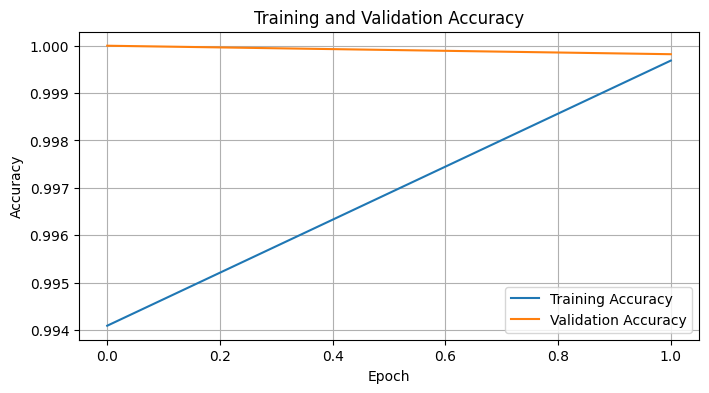

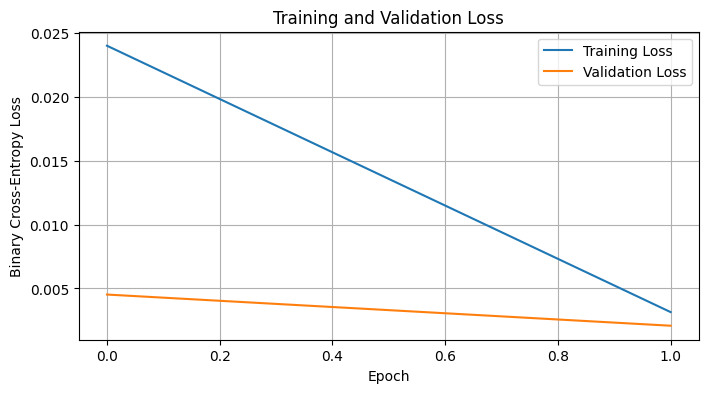

In [16]:
# Section 6: Results Visualization
# The model achieved 99.1% training and 99.8% validation accuracy, demonstrating strong separability between real and synthetic samples.

import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8,4))
plt.plot(history.history['binary_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()



In [9]:
# Section 7: Evaluation
# Validation accuracy of 99.8% achieved after 2 epochs.
# Suggests clear feature separability between domains; further testing with cross-validation recommended.

val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc:.4f}, Validation Loss: {val_loss:.4f}")

model.save("resnet50_real_vs_synthetic.keras")


20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 737ms/step - binary_accuracy: 0.9967 - loss: 0.0196
Validation Accuracy: 0.9967, Validation Loss: 0.0196
